# Modelo Predictivo de Riesgo Crediticio y Optimización de P y L

**Autor:** Rodrigo Antonio Padilla Lara  
**Dataset:** Home Credit Default Risk (Kaggle)  
**Objetivo:** Construir dos modelos distintos para decidir a qué clientes es preferible ofrecer un préstamo (Regresión Logística + WoE y un modelo de Machine Learning con LightGBM), así como realizar un análisis financiero en el que se contrastan distintas políticas de crédito para encontrar el equilibrio entre ofrecer más créditos y reducir las pérdidas por clientes con un mayor grado de morosidad.

## 1. Carga, revisión y limpieza de datos
En esta sección se cargan las fuentes de información y se comprueba que los datos tengan los valores esperados. Para esto, se aplican reglas independientes para detectar anomalías, valores nulos y textos no válidos en variables categóricas y numéricas.

In [1]:
import sys
!{sys.executable} -m pip install lightgbm

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)

import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp

# 1.1 Definimos las rutas y cargamos los archivos

ruta_app = "data/application_train.csv"
ruta_desc = "data/HomeCredit_columns_description.csv"

df_desc = pd.read_csv(ruta_desc, encoding='latin-1', index_col='Row')
df_app = pd.read_csv(ruta_app, encoding='latin-1', nrows=0) 

print(df_desc.shape)
print(df_app.shape)

# 1.2 ¿Hay columnas repetidas? 

columnas = df_app.columns
conteo = columnas.value_counts()
duplicados = conteo[conteo > 1]

if len(duplicados) > 0:
    print(f"Columnas duplicadas encontradas: {list(duplicados.index)}")
else:
    print("Ninguna columna aparece más de una vez.")

# 1.2 ¿Hay variables en 'application' que no están en 'description'? 

resultado = set(df_app.columns) - set(df_desc.index)

if len(resultado) > 0:
    print(f"\nVariables no documentadas: {len(resultado)}")
    for columna in sorted(resultado):
        print(f"- {columna}")
else:
    print("Todas las columnas están documentadas.")

# 1.3 Clasificación de variables 
df_app = pd.read_csv(ruta_app, encoding='latin-1')

columnas_no_numericas = []
columnas_binarias = []
columnas_numericas = []
columnas_vacias = [] 

for col in df_app.columns:
    muestra = df_app[col].head(20)
    muestra_limpia = muestra.dropna() 
    
    if len(muestra_limpia) == 0:
        columnas_vacias.append(col)
        continue
        
    # REGLA 1: NO NUMÉRICA
    es_no_numerica = False
    for val in muestra_limpia:
        try:
            float(val)
        except (ValueError, TypeError):
            es_no_numerica = True
            break
            
    if es_no_numerica:
        columnas_no_numericas.append(col)
        
    # REGLA 2: BINARIA
    es_binaria = False
    if not es_no_numerica: 
        valores_unicos = muestra_limpia.unique()
        solo_ceros_y_unos = all(float(v) in [0.0, 1.0] for v in valores_unicos)
        if solo_ceros_y_unos:
            es_binaria = True
            
    if es_binaria:
        columnas_binarias.append(col)
        
    #  REGLA 3: NUMÉRICA 
    es_numerica = False
    if not es_no_numerica:
        valores_unicos = muestra_limpia.unique()
        tiene_otros_numeros = any(float(v) not in [0.0, 1.0] for v in valores_unicos)
        if tiene_otros_numeros:
            es_numerica = True
            
    if es_numerica:
        columnas_numericas.append(col)

# MOVER LAS FALSAS BINARIAS A LA LISTA DE NUMÉRICAS 
falsas_binarias = [
    'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_MON', 
    'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_DAY', 
    'AMT_REQ_CREDIT_BUREAU_HOUR', 'CNT_CHILDREN'
]

for col in falsas_binarias:
    if col in df_app.columns:
        if col not in columnas_numericas:
            columnas_numericas.append(col)
        if col in columnas_binarias:
            columnas_binarias.remove(col)

print(f"-> Las 6 variables de conteo ya forman parte de la lista 'columnas_numericas'. Total de numéricas: {len(columnas_numericas)}")

# RED DE SEGURIDAD PARA FALSAS BINARIAS 
for col in falsas_binarias:
    if col in df_app.columns:
        df_app[col] = pd.to_numeric(df_app[col], errors='coerce')
        df_app[col] = df_app[col].mask(df_app[col] < 0, np.nan)

print("\n-> Verificación de binarias y falsas binarias aplicada físicamente en df_app.")

# --- Mostrar los resultados ---
print("\n--- CONTEO TOTAL (Reglas Independientes en primeras 20 filas) ---")
print(f"* No numéricas: {len(columnas_no_numericas)}")
print(f"* Binarias (0 y 1): {len(columnas_binarias)}")
print(f"* Numéricas (Continuas/Discretas): {len(columnas_numericas)}")

if len(columnas_vacias) > 0:
    print(f"* No clasificables (puros nulos al inicio): {len(columnas_vacias)}")

total_evaluadas = len(columnas_no_numericas) + len(columnas_binarias) + len(columnas_numericas) + len(columnas_vacias)
print(f"\nTotal columnas procesadas: {total_evaluadas} de {len(df_app.columns)}")

total_filas = len(df_app)
reporte_general = []

# --- 1.4 LIMPIEZA DE NUMÉRICAS ---
for col in columnas_numericas:
    serie = df_app[col]
    nulos_count = pd.to_numeric(serie, errors='coerce').isna().sum()
    pct_nulos = (nulos_count / total_filas) * 100
    reporte_general.append({
        'Columna': col, 'Tipo': 'Numérica', 'Criterio_Nulo': 'No es número',
        'Total_Filas': total_filas, 'Nulos_o_Invalidos': nulos_count, '%_Nulos': round(pct_nulos, 2)
    })

# 1.5 LIMPIEZA DE BINARIAS  
for col in columnas_binarias:
    serie = df_app[col]
    df_app[col] = pd.to_numeric(df_app[col], errors='coerce')
    df_app[col] = df_app[col].where(df_app[col].isin([0, 1, 0.0, 1.0]), np.nan)
    nulos_count = df_app[col].isna().sum()
    pct_nulos = (nulos_count / total_filas) * 100
    reporte_general.append({
        'Columna': col, 'Tipo': 'Binaria', 'Criterio_Nulo': 'Distinto de 0 o 1',
        'Total_Filas': total_filas, 'Nulos_o_Invalidos': nulos_count, '%_Nulos': round(pct_nulos, 2)
    })


# 1.6 LIMPIEZA DE CATEGÓRICAS 
textos_basura = ['', '0', 'nan', 'na', 'null', 'none', '?', 'xna', 'xap']

for col in columnas_no_numericas:
    serie_str = df_app[col].astype(str).str.strip().str.lower()
    mask_basura = df_app[col].isna() | serie_str.isin(textos_basura)
    df_app[col] = df_app[col].mask(mask_basura, np.nan)
    nulos_count = mask_basura.sum()
    pct_nulos = (nulos_count / total_filas) * 100
    
    reporte_general.append({
        'Columna': col, 'Tipo': 'No Numérica', 'Criterio_Nulo': 'Vacíos o textos basura',
        'Total_Filas': total_filas, 'Nulos_o_Invalidos': nulos_count, '%_Nulos': round(pct_nulos, 2)
    })

for col in columnas_no_numericas:
    df_app[col] = df_app[col].str.strip().str.lower()

# --- ELIMINACIÓN DE LAS 28 VARIABLES ---
variables_a_eliminar = [
    'COMMONAREA_MODE', 'COMMONAREA_MEDI', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_MEDI',
    'LIVINGAPARTMENTS_MODE', 'LIVINGAPARTMENTS_MEDI', 'FLOORSMIN_MODE', 'FLOORSMIN_MEDI',
    'YEARS_BUILD_MODE', 'YEARS_BUILD_MEDI', 'LANDAREA_MODE', 'LANDAREA_MEDI',
    'BASEMENTAREA_MODE', 'BASEMENTAREA_MEDI', 'NONLIVINGAREA_MODE', 'NONLIVINGAREA_MEDI',
    'ELEVATORS_MODE', 'ELEVATORS_MEDI', 'APARTMENTS_MODE', 'APARTMENTS_MEDI',
    'ENTRANCES_MODE', 'ENTRANCES_MEDI', 'LIVINGAREA_MODE', 'LIVINGAREA_MEDI',
    'FLOORSMAX_MODE', 'FLOORSMAX_MEDI', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BEGINEXPLUATATION_MEDI'
]

columnas_numericas_restantes = [col for col in columnas_numericas if col not in variables_a_eliminar]

df_app = df_app.drop(columns=variables_a_eliminar, errors='ignore')

# --- CONTEO ACTUALIZADO TRAS ELIMINAR LAS 28 VARIABLES ---
print("\n" + "="*50)
print(" CONTEO ACTUALIZADO DE VARIABLES (Tras eliminar las 28) ")
print("="*50)
print(f"* Numéricas restantes: {len(columnas_numericas_restantes)}")
print(f"* No numéricas (Categóricas): {len(columnas_no_numericas)}")
print(f"* Binarias: {len(columnas_binarias)}")
print(f"Total general de variables activas: {len(columnas_numericas_restantes) + len(columnas_no_numericas) + len(columnas_binarias)}")
print("="*50)

# 1.7 PROCESAMIENTO Y CÁLCULOS POR SUBGRUPOS 

# Subgrupo 1: Normalizadas y Proporciones
marcadores_grupo_1 = ['_AVG', 'EXT_SOURCE', 'REGION_POPULATION_RELATIVE', 'TOTALAREA_MODE']
grupo1_normalizadas = [col for col in columnas_numericas_restantes if any(marcador in col for marcador in marcadores_grupo_1)]

for col in grupo1_normalizadas:
    df_app[col] = pd.to_numeric(df_app[col], errors='coerce')
    df_app[col] = df_app[col].mask((df_app[col] < 0) | (df_app[col] > 1), np.nan)

# Subgrupo 2: Montos Monetarios (Estrictamente dinero, excluyendo requerimientos de buró) ---
grupo2_montos = [
    col for col in columnas_numericas_restantes 
    if col.startswith('AMT_') and not col.startswith('AMT_REQ_')
]

for col in grupo2_montos:
    df_app[col] = pd.to_numeric(df_app[col], errors='coerce')
    df_app[col] = df_app[col].mask(df_app[col] <= 0, np.nan)

# Subgrupo 3: Conteos, frecuencias y edades
marcadores_grupo_3 = ['OBS_', 'DEF_', 'CNT_', 'AMT_REQ_', 'OWN_CAR_AGE']
grupo3_conteos = [col for col in columnas_numericas_restantes if any(marcador in col for marcador in marcadores_grupo_3)]

for col in grupo3_conteos:
    df_app[col] = pd.to_numeric(df_app[col], errors='coerce')
    df_app[col] = df_app[col].mask(df_app[col] < 0, np.nan)

# Subgrupo 4 DAYS. Crear la bandera de desempleo ANTES de enmascarar o borrar los valores
if 'DAYS_EMPLOYED' in df_app.columns:
    df_app['IS_UNEMPLOYED'] = (df_app['DAYS_EMPLOYED'] == 365243).astype(int)
else:
    df_app['IS_UNEMPLOYED'] = 0

# Subgrupo 4.2 DAYS. Definir el Grupo 4 de variables temporales DAYS_
grupo4_days = [col for col in columnas_numericas_restantes if 'DAYS_' in col]

# Subgrupo 4.3 DAYS. Asegurar que IS_UNEMPLOYED esté en el grupo 4
if 'IS_UNEMPLOYED' not in grupo4_days:
    grupo4_days.append('IS_UNEMPLOYED')

# Subgrupo 4.4. DAYS. Limpiar valores anómalos o mayores a 0 en las variables temporales (excepto en la bandera binaria)
for col in grupo4_days:
    if col != 'IS_UNEMPLOYED':
        df_app[col] = df_app[col].mask((df_app[col] > 0) | (df_app[col] == 365243), np.nan)


# Subgrupo 5: Calificaciones de Región y Horas
columnas_ratings = ['REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY']
for col in columnas_ratings:
    if col in df_app.columns:
        df_app[col] = pd.to_numeric(df_app[col], errors='coerce')
        df_app[col] = df_app[col].where(df_app[col].isin([1, 2, 3]), np.nan)

col_hora = 'HOUR_APPR_PROCESS_START'
if col_hora in df_app.columns:
    df_app[col_hora] = pd.to_numeric(df_app[col_hora], errors='coerce')
    df_app[col_hora] = df_app[col_hora].mask((df_app[col_hora] < 0) | (df_app[col_hora] > 23), np.nan)



Defaulting to user installation because normal site-packages is not writeable
(219, 4)
(0, 122)
Ninguna columna aparece más de una vez.
Todas las columnas están documentadas.
-> Las 6 variables de conteo ya forman parte de la lista 'columnas_numericas'. Total de numéricas: 73

-> Verificación de binarias y falsas binarias aplicada físicamente en df_app.

--- CONTEO TOTAL (Reglas Independientes en primeras 20 filas) ---
* No numéricas: 16
* Binarias (0 y 1): 33
* Numéricas (Continuas/Discretas): 73

Total columnas procesadas: 122 de 122

 CONTEO ACTUALIZADO DE VARIABLES (Tras eliminar las 28) 
* Numéricas restantes: 45
* No numéricas (Categóricas): 16
* Binarias: 33
Total general de variables activas: 94


## 2. Ingeniería de Variables (Feature Engineering)
Se construyen ratios financieros clave (como el apalancamiento de crédito respecto al ingreso, la carga de anualidad y métricas familiares) y se tratan los valores atípicos estableciendo un límite en el percentil 99, calculado sobre los datos de entrenamiento y posteriormente aplicado a los conjuntos de validación y test. De esta manera, se evita que información de estos conjuntos influya en el proceso de entrenamiento del modelo (data leakage).

In [2]:
# --- 2.1 SUBGRUPO 6: Derived_Features (Ratios Financieros y Estructurales) ---
df_app['RATIO_CREDIT_INCOME'] = df_app['AMT_CREDIT'] / df_app['AMT_INCOME_TOTAL']
df_app['RATIO_ANNUITY_INCOME'] = df_app['AMT_ANNUITY'] / df_app['AMT_INCOME_TOTAL']
df_app['RATIO_ANNUITY_CREDIT'] = df_app['AMT_ANNUITY'] / df_app['AMT_CREDIT']
df_app['RATIO_GOODS_CREDIT'] = df_app['AMT_GOODS_PRICE'] / df_app['AMT_CREDIT']
df_app['RATIO_INCOME_PER_FAMILY'] = df_app['AMT_INCOME_TOTAL'] / df_app['CNT_FAM_MEMBERS'].replace(0, np.nan)
df_app['RATIO_INCOME_PER_CHILD'] = df_app['AMT_INCOME_TOTAL'] / df_app['CNT_CHILDREN'].replace(0, np.nan)
df_app['RATIO_INCOME_PER_DAY_EMPLOYED'] = df_app['AMT_INCOME_TOTAL'] / df_app['DAYS_EMPLOYED'].abs().replace(0, np.nan)
df_app['RATIO_EMPLOYED_TO_BIRTH'] = df_app['DAYS_EMPLOYED'] / df_app['DAYS_BIRTH']
df_app['RATIO_LIVING_TOTAL_AREA'] = df_app['LIVINGAREA_AVG'] / df_app['TOTALAREA_MODE'].replace(0, np.nan)
df_app['RATIO_COMMON_TOTAL_AREA'] = df_app['COMMONAREA_AVG'] / df_app['TOTALAREA_MODE'].replace(0, np.nan)

derived_features_list = [
    'RATIO_CREDIT_INCOME', 
    'RATIO_ANNUITY_INCOME', 
    'RATIO_ANNUITY_CREDIT', 
    'RATIO_GOODS_CREDIT', 
    'RATIO_INCOME_PER_FAMILY',
    'RATIO_INCOME_PER_CHILD',
    'RATIO_INCOME_PER_DAY_EMPLOYED',
    'RATIO_EMPLOYED_TO_BIRTH',
    'RATIO_LIVING_TOTAL_AREA',
    'RATIO_COMMON_TOTAL_AREA'
]

for col in derived_features_list:
    df_app[col] = df_app[col].replace([np.inf, -np.inf], np.nan)

print(f"-> Se crearon {len(derived_features_list)} variables en el nuevo subgrupo 'Derived_Features'.")

# 2.2 BANDERAS DE AUSENCIA (_IS_MISSING) ANTES DE IMPUTAR 
columnas_clave_para_flags = [
    'EXT_SOURCE_1',
    'EXT_SOURCE_3',
    'OWN_CAR_AGE',
    'DAYS_EMPLOYED',
    'OCCUPATION_TYPE',
]
for col in columnas_clave_para_flags:
  if col in df_app.columns:
    df_app[f'{col}_IS_MISSING'] = df_app[col].isna().astype(int)

#Desfragmentar
df_app = df_app.copy()

# --- 2.3 CONVERTIR DÍAS A AÑOS POSITIVOS ---
if 'DAYS_BIRTH' in df_app.columns:
  df_app['DAYS_BIRTH'] = df_app['DAYS_BIRTH'] * -1 / 365
if 'DAYS_EMPLOYED' in df_app.columns:
  df_app['DAYS_EMPLOYED'] = df_app['DAYS_EMPLOYED'] * -1 / 365

# --- 2.4. LIMPIEZA DEL ID ---
col_id = 'SK_ID_CURR'
if col_id in df_app.columns:
  df_app[col_id] = pd.to_numeric(df_app[col_id], errors='coerce')
  df_app = df_app.dropna(subset=[col_id])
  df_app = df_app[df_app[col_id] > 0]

# --- 2.5. TRAIN / TEST SPLIT ( antes de tocar medianas) ---
from sklearn.model_selection import train_test_split

X = df_app.drop(columns=['TARGET', 'SK_ID_CURR'], errors='ignore')
y = df_app['TARGET']

# Separamos primero un 15% como Test final intocable
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Del 85% restante, sacamos Train (80%) y Validación (20% para el early stopping)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20, random_state=42, stratify=y_temp
)

print(f'Train: {X_train.shape[0]} | Validación: {X_val.shape[0]} | Test: {X_test.shape[0]}')

# --- 2.6 WINSORIZACIÓN (Calculada estrictamente en X_train) ---
variables_a_winsorizar = [
    'AMT_REQ_CREDIT_BUREAU_YEAR', 'OBS_30_CNT_SOCIAL_CIRCLE',
    'OBS_60_CNT_SOCIAL_CIRCLE', 'AMT_GOODS_PRICE',
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
]

for col in variables_a_winsorizar:
    if col in X_train.columns:
        limite_superior = X_train[col].quantile(0.99)
        X_train[col] = X_train[col].clip(upper=limite_superior)
        X_val[col] = X_val[col].clip(upper=limite_superior)
        X_test[col] = X_test[col].clip(upper=limite_superior)

# --- 2.7. IMPUTACIÓN DE NUMÉRICAS (Mediana de X_train) ---
todas_las_numericas = columnas_numericas_restantes + derived_features_list
for col in todas_las_numericas:
    if col in X_train.columns:
        mediana_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(mediana_val)
        X_val[col] = X_val[col].fillna(mediana_val)
        X_test[col] = X_test[col].fillna(mediana_val)

# ---  IMPUTACIÓN Y ALINEACIÓN ESTRICTA DE CATEGÓRICAS ---
for col in columnas_no_numericas:
    if col in X_train.columns:
        # Rellenar nulos con 'MISSING' y asegurar que sean texto plano temporalmente
        X_train[col] = X_train[col].fillna('MISSING').astype(str)
        X_val[col] = X_val[col].fillna('MISSING').astype(str)
        X_test[col] = X_test[col].fillna('MISSING').astype(str)
        
        # Extraer las categorías únicas oficiales basadas EXCLUSIVAMENTE en el Train
        categorias_train = list(X_train[col].unique())
        
        # Forzar el tipo categórico de pandas usando el mismo diccionario de categorías en los 3 sets
        X_train[col] = pd.Categorical(X_train[col], categories=categorias_train)
        X_val[col] = pd.Categorical(X_val[col], categories=categorias_train)
        X_test[col] = pd.Categorical(X_test[col], categories=categorias_train)


-> Se crearon 10 variables en el nuevo subgrupo 'Derived_Features'.
Train: 209107 | Validación: 52277 | Test: 46127


## 3. Modelo de Regresión Logística con Weight of Evidence (WoE)
Se transforman las variables categóricas utilizando Information Value (IV > 0.02) y Weight of Evidence (WoE), mientras que las variables numéricas se estandarizan para colocarlas en una escala comparable antes de incorporarlas a la regresión logística y, se ajustan las probabilidades de incumplimiento estimadas mediante Platt Scaling.

Variables numéricas escaladas: 64
Variables categóricas con IV > 0.02 seleccionadas: 9 de 16
Dimensiones Train WoE: (209107, 9)
Dimensiones de matriz final para LR (Train): (209107, 73)


C:\Users\drago\anaconda3\Lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(



[RESULTADO] ROC-AUC de la Regresión Logística (Numéricas + WoE + Calibrada): 0.7463


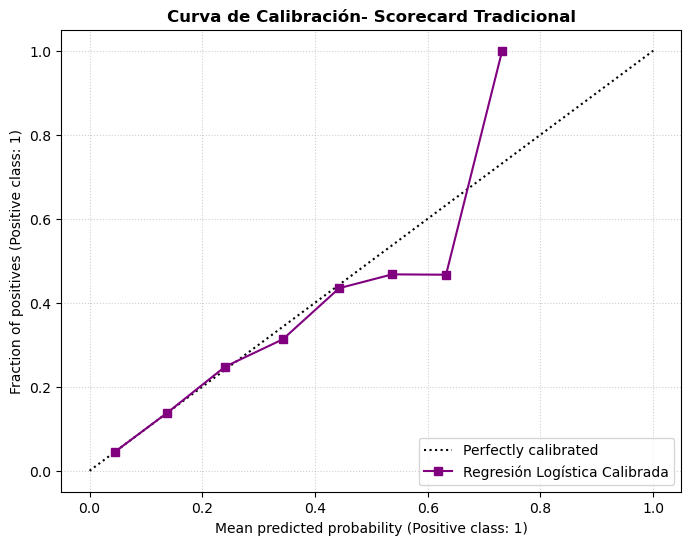

ln(P / (1 - P)) = (-0.2952) +0.0322 · [AMT_INCOME_TOTAL] -0.0588 · [AMT_CREDIT] +0.1813 · [AMT_ANNUITY] -0.2105 · [AMT_GOODS_PRICE] +0.0046 · [REGION_POPULATION_RELATIVE] +0.0376 · [DAYS_BIRTH] -0.1449 · [DAYS_EMPLOYED] +0.0218 · [DAYS_REGISTRATION] +0.0594 · [DAYS_ID_PUBLISH] +0.0083 · [OWN_CAR_AGE] -0.0752 · [CNT_FAM_MEMBERS] -0.0799 · [REGION_RATING_CLIENT] +0.1546 · [REGION_RATING_CLIENT_W_CITY] -0.0134 · [HOUR_APPR_PROCESS_START] -0.1853 · [EXT_SOURCE_1] -0.3862 · [EXT_SOURCE_2] -0.4791 · [EXT_SOURCE_3] +0.0384 · [APARTMENTS_AVG] +0.0127 · [BASEMENTAREA_AVG] -0.0066 · [YEARS_BEGINEXPLUATATION_AVG] -0.0174 · [YEARS_BUILD_AVG] -0.0090 · [COMMONAREA_AVG] -0.0175 · [ELEVATORS_AVG] -0.0376 · [ENTRANCES_AVG] -0.0435 · [FLOORSMAX_AVG] +0.0010 · [FLOORSMIN_AVG] +0.0050 · [LANDAREA_AVG] +0.0217 · [LIVINGAPARTMENTS_AVG] +0.0028 · [LIVINGAREA_AVG] +0.0111 · [NONLIVINGAPARTMENTS_AVG] +0.0046 · [NONLIVINGAREA_AVG] -0.0279 · [TOTALAREA_MODE] +0.0432 · [OBS_30_CNT_SOCIAL_CIRCLE] +0.0351 · [DEF_3

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
import matplotlib.pyplot as plt

#3.1 Juntar las numéricas base con las derived features ya imputadas y limpiadas 
todas_las_numericas_completas = [col for col in (todas_las_numericas + derived_features_list) if col in X_train.columns]

# 3.2 Escalado estándar (para Regresión Logística)
scaler = StandardScaler()
X_train_num_scaled = pd.DataFrame(scaler.fit_transform(X_train[todas_las_numericas_completas]), 
                                  columns=todas_las_numericas_completas, index=X_train.index)
X_val_num_scaled = pd.DataFrame(scaler.transform(X_val[todas_las_numericas_completas]), 
                                columns=todas_las_numericas_completas, index=X_val.index)
X_test_num_scaled = pd.DataFrame(scaler.transform(X_test[todas_las_numericas_completas]), 
                                 columns=todas_las_numericas_completas, index=X_test.index)

print(f"Variables numéricas escaladas: {X_train_num_scaled.shape[1]}")

# 3.3. CÁLCULO DE WOE, IV Y CONSTRUCCIÓN DE MATRICES 

def calcular_woe_iv(df_x, df_y, col, target_col='TARGET'):
    df_temp = pd.DataFrame({col: df_x[col], 'target': df_y})
    
    stats = df_temp.groupby(col, observed=False)['target'].agg(['count', 'sum']).rename(columns={'count': 'total', 'sum': 'bads'})
    stats['goods'] = stats['total'] - stats['bads']
    
    total_bads = stats['bads'].sum()
    total_goods = stats['goods'].sum()
    
    stats['bads'] = stats['bads'].replace(0, 0.5)
    stats['goods'] = stats['goods'].replace(0, 0.5)
    
    stats['dist_bad'] = stats['bads'] / total_bads
    stats['dist_good'] = stats['goods'] / total_goods
    
    stats['woe'] = np.log(stats['dist_good'] / stats['dist_bad'])
    stats['iv'] = (stats['dist_good'] - stats['dist_bad']) * stats['woe']
    
    iv_total = stats['iv'].sum()
    return iv_total, stats['woe'].to_dict()

iv_resultados = {}
woe_dicts = {}

for col in columnas_no_numericas:
    if col in X_train.columns:
        iv, woe_dict = calcular_woe_iv(X_train, y_train, col)
        iv_resultados[col] = iv
        woe_dicts[col] = woe_dict

# Filtrar primero las variables con IV > 0.02 antes de usarlas
variables_seleccionadas_iv = [col for col, iv in iv_resultados.items() if iv > 0.02]
print(f"Variables categóricas con IV > 0.02 seleccionadas: {len(variables_seleccionadas_iv)} de {len(columnas_no_numericas)}")

# Inicializar los DataFrames para las tres particiones
X_train_woe = pd.DataFrame(index=X_train.index)
X_val_woe = pd.DataFrame(index=X_val.index)
X_test_woe = pd.DataFrame(index=X_test.index)

#  Mapear los diccionarios de WoE en los tres sets de manera limpia
for col in variables_seleccionadas_iv:
    mapeo_woe = woe_dicts[col]
    X_train_woe[col + '_woe'] = X_train[col].astype(str).map(mapeo_woe).fillna(0)
    X_val_woe[col + '_woe'] = X_val[col].astype(str).map(mapeo_woe).fillna(0)
    X_test_woe[col + '_woe'] = X_test[col].astype(str).map(mapeo_woe).fillna(0)

print(f"Dimensiones Train WoE: {X_train_woe.shape}")

# --- 3. CONCATENACIÓN FINAL (Numéricas Escaladas + WoE Categóricas) ---
X_train_lr = pd.concat([X_train_num_scaled, X_train_woe], axis=1)
X_val_lr = pd.concat([X_val_num_scaled, X_val_woe], axis=1)
X_test_lr = pd.concat([X_test_num_scaled, X_test_woe], axis=1)

print(f"Dimensiones de matriz final para LR (Train): {X_train_lr.shape}")

# 1. Modelo base con pesos ajustados para clases desbalanceadas
lr_base = LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced', solver='saga', penalty='l2', C=0.1)
lr_base.fit(X_train_lr, y_train)

# 2. Calibrador posterior utilizando el conjunto de validación independiente (cv='prefit')
# Esto corrige la distorsión de probabilidades sin reentrenar los coeficientes principales
calibrated_lr = CalibratedClassifierCV(estimator=lr_base, method='sigmoid', cv='prefit')
calibrated_lr.fit(X_val_lr, y_val)

# Evaluación en el set de Test final
y_pred_lr_calib = calibrated_lr.predict_proba(X_test_lr)[:, 1]
auc_lr_calib = roc_auc_score(y_test, y_pred_lr_calib)

print(f"\n[RESULTADO] ROC-AUC de la Regresión Logística (Numéricas + WoE + Calibrada): {auc_lr_calib:.4f}")

# --- 5. CURVA DE CALIBRACIÓN ---
fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    y_test, y_pred_lr_calib, 
    n_bins=10, 
    name='Regresión Logística Calibrada', 
    ax=ax, 
    color='purple'
)
plt.title('Curva de Calibración- Scorecard Tradicional', fontsize=12, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 1. Extraer intercepto y coeficientes del modelo entrenado
intercepto = lr_base.intercept_[0]
coeficientes = lr_base.coef_[0]
nombres_features = X_train_lr.columns

# 2. Construir la ecuación de Log-Odds paso a paso
terminos = [f"({intercepto:+.4f})"]
for coef, name in zip(coeficientes, nombres_features):
    if abs(coef) > 1e-4:  # Opcional: filtrar coeficientes insignificantes
        terminos.append(f"{coef:+.4f} · [{name}]")

formula_completa = "ln(P / (1 - P)) = " + " ".join(terminos)
print(formula_completa)

## 4. Modelado predictivo con LightGBM
Aquí se entrena el modelo final utilizando un algoritmo de gradiente potenciado, es decir, un modelo que aprende por pasos mediante la construcción de árboles de decisión uno tras otro, donde cada nuevo árbol busca corregir los errores de los anteriores.

Para evitar el sobreajuste (es decir, que el modelo memorice los datos de entrenamiento en lugar de aprender patrones que pueda generalizar a datos nuevos), se utiliza early stopping. Este mecanismo detiene automáticamente el entrenamiento cuando el desempeño del modelo en el conjunto de validación deja de mejorar.

Los datos se dividen en tres grupos separados: 1) Train, donde el modelo aprende de los datos; 2) Validación, que permite evaluar su desempeño durante el entrenamiento y determinar cuándo detenerlo; y 3) Test, que se reserva como una prueba final con datos que el modelo no utilizó durante su entrenamiento ni para la selección de la duración del mismo.

Las métricas finales se calculan únicamente sobre el conjunto de test, utilizando ROC-AUC, Gini y el estadístico KS.

C:\Users\Rodrigo Padilla\AppData\Roaming\Python\Python313\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 16881, number of negative: 192226
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.152068 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8906
[LightGBM] [Info] Number of data points in the train set: 209107, number of used features: 103
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432483
[LightGBM] [Info] Start training from score -2.432483
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Li

C:\Users\drago\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


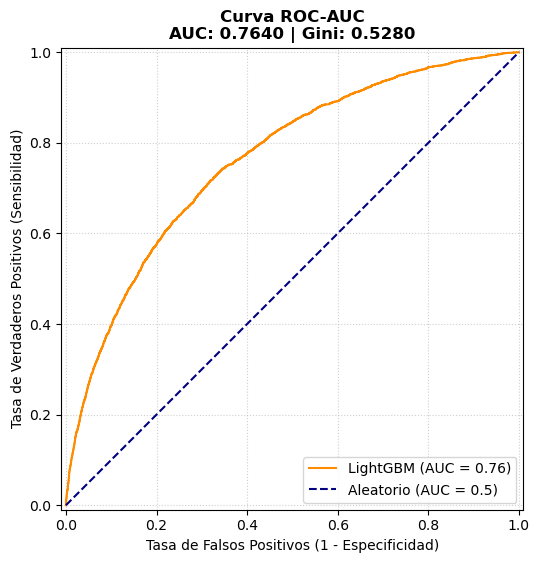

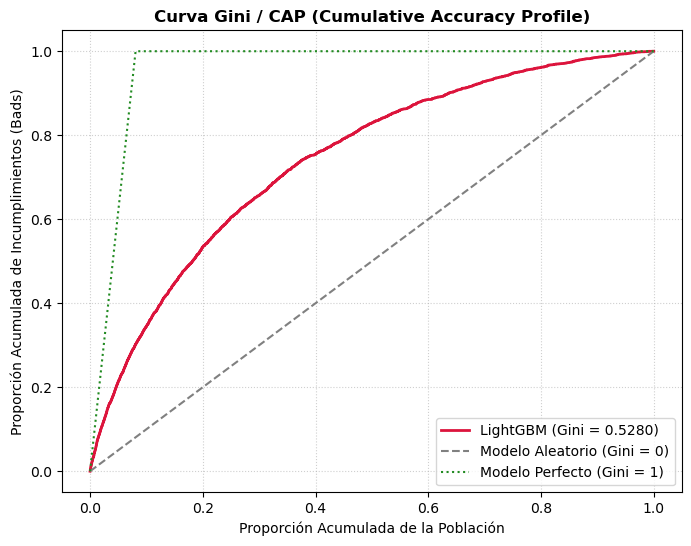

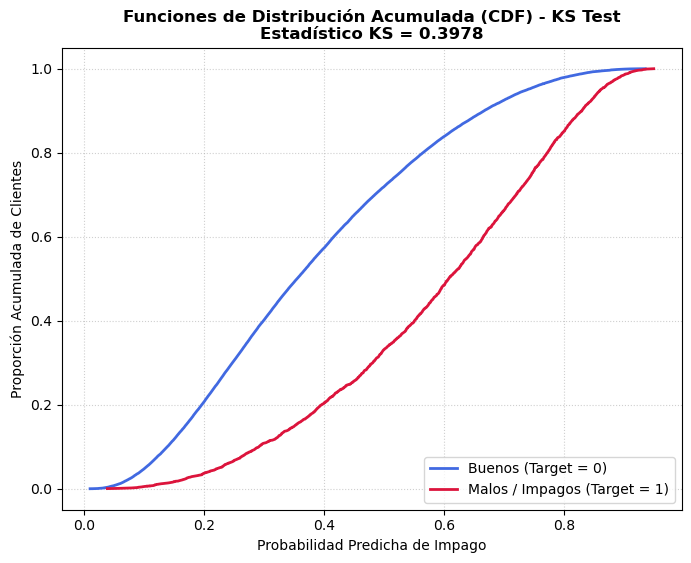

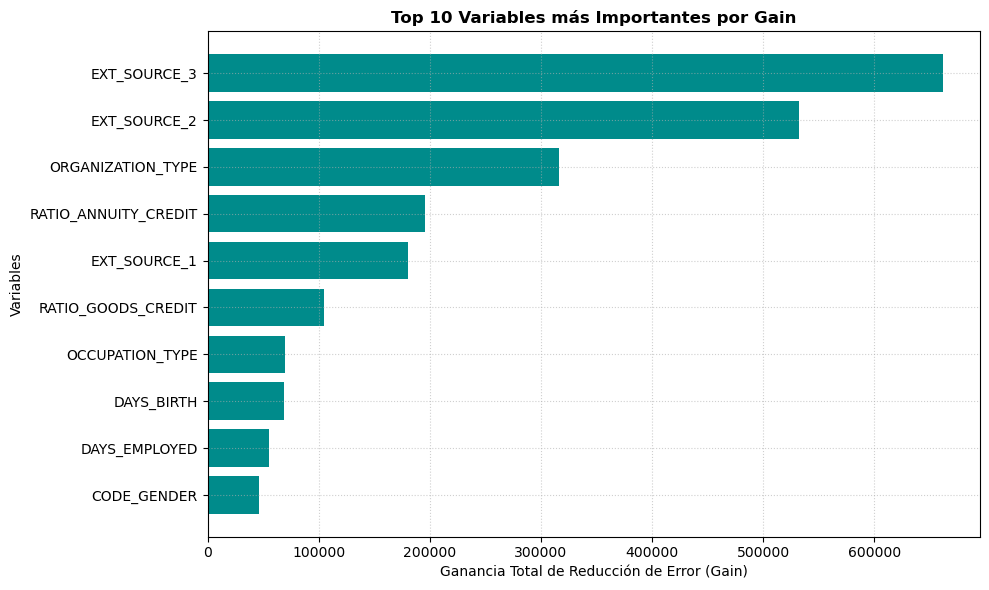

In [4]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp


# ---4.1 . ENTRENAMIENTO DE LIGHTGBM  ---
model = lgb.LGBMClassifier(
    n_estimators=1000,          
    learning_rate=0.02,         
    max_depth=5,
    is_unbalance=True,
    metric='auc',               
    random_state=42,
    n_jobs=-1
)


model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],  
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# --- 4.2. EVALUACIÓN FINAL EN EL SET DE TEST ---
y_pred_proba = model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_pred_proba)
gini_score = 2 * auc_score - 1

buenos_scores = y_pred_proba[y_test == 0]
malos_scores = y_pred_proba[y_test == 1]
ks_stat, _ = ks_2samp(buenos_scores, malos_scores)

# 4.2 Calcular las ECDF (Empirical Cumulative Distribution Function)
x_buenos = np.sort(buenos_scores)
y_buenos = np.arange(1, len(x_buenos) + 1) / len(x_buenos)

x_malos = np.sort(malos_scores)
y_malos = np.arange(1, len(x_malos) + 1) / len(x_malos)


print("\n" + "="*40)
print(" RESULTADOS EN EL SET DE TEST ")
print("="*40)
print(f"ROC - AUC     : {auc_score:.4f}")
print(f"Gini          : {gini_score:.4f}")
print(f"Estadístico KS: {ks_stat:.4f}")
print("="*40)

import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# --- 4.3 GRÁFICA DE LA CURVA ROC-AUC ---
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name='LightGBM', color='darkorange')

# Línea base aleatoria
ax.plot([0, 1], [0, 1], linestyle='--', color='navy', label='Aleatorio (AUC = 0.5)')
ax.set_title(f'Curva ROC-AUC\nAUC: {auc_score:.4f} | Gini: {gini_score:.4f}', fontsize=12, fontweight='bold')
ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='lower right')
plt.show()

# --- 4.4. GRÁFICA DE LA CURVA GINI (CAP - Cumulative Accuracy Profile) ---
# Preparamos los datos ordenándolos de mayor a menor probabilidad de impago
df_gini = pd.DataFrame({'y_true': y_test.values, 'y_prob': y_pred_proba})
df_gini = df_gini.sort_values(by='y_prob', ascending=False).reset_index(drop=True)

total_bads = df_gini['y_true'].sum()
total_obs = len(df_gini)

# Calculamos proporciones acumuladas
df_gini['cum_bads'] = df_gini['y_true'].cumsum() / total_bads
df_gini['cum_pop'] = (df_gini.index + 1) / total_obs

# Insertamos el origen (0, 0)
cum_pop = np.insert(df_gini['cum_pop'].values, 0, 0)
cum_bads = np.insert(df_gini['cum_bads'].values, 0, 0)

# Coordenadas para el modelo 
perfect_pop = [0, total_bads / total_obs, 1.0]
perfect_bads = [0, 1.0, 1.0]

plt.figure(figsize=(8, 6))
plt.plot(cum_pop, cum_bads, label=f'LightGBM (Gini = {gini_score:.4f})', color='crimson', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Modelo Aleatorio (Gini = 0)')
plt.plot(perfect_pop, perfect_bads, linestyle=':', color='forestgreen', label='Modelo Perfecto (Gini = 1)')

plt.title('Curva Gini / CAP (Cumulative Accuracy Profile)', fontsize=12, fontweight='bold')
plt.xlabel('Proporción Acumulada de la Población')
plt.ylabel('Proporción Acumulada de Incumplimientos (Bads)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.show()

# 4.5 Gráfica de las CDFs
plt.figure(figsize=(8, 6))
plt.plot(x_buenos, y_buenos, label='Buenos (Target = 0)', color='royalblue', linewidth=2)
plt.plot(x_malos, y_malos, label='Malos / Impagos (Target = 1)', color='crimson', linewidth=2)

plt.title(f'Funciones de Distribución Acumulada (CDF) - KS Test\nEstadístico KS = {ks_stat:.4f}', fontsize=12, fontweight='bold')
plt.xlabel('Probabilidad Predicha de Impago', fontsize=10)
plt.ylabel('Proporción Acumulada de Clientes', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.show()

# 4.6 Extraer la importancia por Gain usando el booster nativo de LightGBM
feature_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Gain': model.booster_.feature_importance(importance_type='gain')
})

# Ordenar de mayor a menor y filtrar estrictamente el Top 10
top_10 = feature_imp.sort_values(by='Gain', ascending=False).head(10)

#  Generar la gráfica de barras horizontales
plt.figure(figsize=(10, 6))
plt.barh(top_10['Feature'][::-1], top_10['Gain'][::-1], color='darkcyan')

plt.title('Top 10 Variables más Importantes por Gain', fontsize=12, fontweight='bold')
plt.xlabel('Ganancia Total de Reducción de Error (Gain)', fontsize=10)
plt.ylabel('Variables', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## 5. Simulación Financiera y Evaluación de Políticas (P y L)
Se simulan tres políticas de originación (Conservadora, Equilibrada y Agresiva) calculando la pérdida esperada (EL) y el beneficio neto para la institución.

In [5]:
# --- 5.1 PARÁMETROS FINANCIEROS DE SUPUESTO Y UMBRALES DE PROBABILIDAD DE IMPAGO (PD) ---
LGD = 0.75               
TASA_INTERES = 0.35      
COSTO_FONDO = 0.15       
SPREAD_NETO = TASA_INTERES - COSTO_FONDO 


# Si la probabilidad predicha es MENOR o IGUAL al umbral, el crédito se APRUEBA.
umbrales = {
    'Conservador': 0.06, 
    'Equilibrado': 0.10,  
    'Agresivo': 0.15     
}

resultados_simulacion = []

# Obtenemos el EAD (Exposure at Default) desde el monto de crédito en test
ead_test = X_test['AMT_CREDIT'].values
y_true_test = y_test.values

for politica, umbral in umbrales.items():
    # 1. Regla de decisión: 1 si se aprueba (prob <= umbral), 0 si se rechaza
    aprobados_mask = y_pred_proba <= umbral
    
    # Métricas operativas básicas
    total_solicitudes = len(y_pred_proba)
    total_aprobados = aprobados_mask.sum()
    tasa_aprobacion = (total_aprobados / total_solicitudes) * 100
    
    if total_aprobados == 0:
        continue
        
    # Subconjunto de créditos aprobados
    ead_aprobados = ead_test[aprobados_mask]
    y_aprobados = y_true_test[aprobados_mask]
    pd_aprobados = y_pred_proba[aprobados_mask]
    
    # 2. Tasa de impago esperada en la población aprobada (Bad Rate real observado)
    tasa_impago_real = (y_aprobados.sum() / total_aprobados) * 100
    
    # 3. Cálculo financiero por cliente aprobado
    # Ingreso financiero por margen: EAD * SPREAD_NETO para los que pagan (y=0)
    ingresos_buenos = (ead_aprobados[y_aprobados == 0] * SPREAD_NETO).sum()
    
    # Pérdida esperada total (EL = PD * LGD * EAD)
    # Usamos la pérdida teórica esperada individual o el castigo real de los malos
    perdida_total = (pd_aprobados * LGD * ead_aprobados).sum()
    
    # Beneficio neto total de la política / promedio por cliente
    beneficio_neto_total = ingresos_buenos - perdida_total
    beneficio_neto_promedio = beneficio_neto_total / total_aprobados
    
    resultados_simulacion.append({
        'Política': politica,
        'Umbral PD': umbral,
        'Tasa Aprobación (%)': round(tasa_aprobacion, 2),
        'Bad Rate Esperado (%)': round(tasa_impago_real, 2),
        'Pérdida Total Esperada ($)': round(perdida_total, 2),
        'Beneficio Neto Promedio ($)': round(beneficio_neto_promedio, 2)
    })

# --- TABLA DE DECISIÓN EJECUTIVA ---
df_dashboard = pd.DataFrame(resultados_simulacion)
print("\n" + "="*120)
print(" SIMULACIÓN FINANCIERA Y P y L POR UMBRALES DE RIESGO ")
print("="*120)
print(df_dashboard.to_string(index=False))
print("="*120)


 SIMULACIÓN FINANCIERA Y P y L POR UMBRALES DE RIESGO 
   Política  Umbral PD  Tasa Aprobación (%)  Bad Rate Esperado (%)  Pérdida Total Esperada ($)  Beneficio Neto Promedio ($)
Conservador       0.06                 1.13                   0.58                  9597738.37                     93926.48
Equilibrado       0.10                 4.36                   0.94                 64077646.64                     84789.63
   Agresivo       0.15                10.92                   1.19                243777256.22                     72283.12
